<a href="https://colab.research.google.com/github/jayasai-m/ML_INLAB/blob/main/Task_4_postlab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Dataset Shape: (20640, 8)
   MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  Latitude  \
0  8.3252      41.0  6.984127   1.023810       322.0  2.555556     37.88   
1  8.3014      21.0  6.238137   0.971880      2401.0  2.109842     37.86   
2  7.2574      52.0  8.288136   1.073446       496.0  2.802260     37.85   
3  5.6431      52.0  5.817352   1.073059       558.0  2.547945     37.85   
4  3.8462      52.0  6.281853   1.081081       565.0  2.181467     37.85   

   Longitude  
0    -122.23  
1    -122.22  
2    -122.24  
3    -122.25  
4    -122.25  

 Linear Regression
MAE : 0.5332
MSE : 0.5559
RMSE: 0.7456
R² Score: 0.5758

 Support Vector Regression
MAE : 0.3986
MSE : 0.357
RMSE: 0.5975
R² Score: 0.7276

 Decision Tree Regression
MAE : 0.4547
MSE : 0.4952
RMSE: 0.7037
R² Score: 0.6221


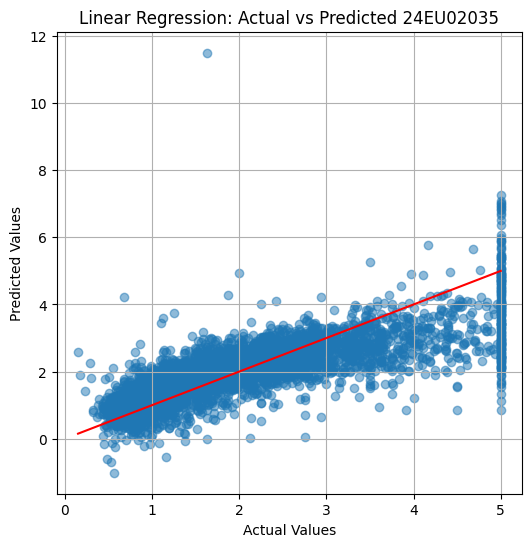

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.svm import SVR
from sklearn.tree import DecisionTreeRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

housing = fetch_california_housing()

X = pd.DataFrame(housing.data, columns=housing.feature_names)
y = housing.target

print("Dataset Shape:", X.shape)
print(X.head())

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

lr = LinearRegression()
lr.fit(X_train, y_train)
lr_pred = lr.predict(X_test)

svr = SVR(kernel="rbf")
svr.fit(X_train_scaled, y_train)
svr_pred = svr.predict(X_test_scaled)

dt = DecisionTreeRegressor(random_state=42)
dt.fit(X_train, y_train)
dt_pred = dt.predict(X_test)

def evaluate(name, actual, predicted):
    mae = mean_absolute_error(actual, predicted)
    mse = mean_squared_error(actual, predicted)
    rmse = np.sqrt(mse)
    r2 = r2_score(actual, predicted)

    print("\n", name)
    print("MAE :", round(mae, 4))
    print("MSE :", round(mse, 4))
    print("RMSE:", round(rmse, 4))
    print("R² Score:", round(r2, 4))

evaluate("Linear Regression", y_test, lr_pred)
evaluate("Support Vector Regression", y_test, svr_pred)
evaluate("Decision Tree Regression", y_test, dt_pred)

plt.figure(figsize=(6,6))
plt.scatter(y_test, lr_pred, alpha=0.5)
plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    'r'
)
plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("Linear Regression: Actual vs Predicted 24EU02035")
plt.grid(True)
plt.show()